In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_india = pd.read_csv("VISA_Details_2010-2013-oct.csv")

df_india.head()
# df_india.info()

,COUNTRY,MISSION,VISA ISSUE DATE,EMPLOYMENT VISA,TOURIST VISA,BUSINESS VISA,CONFERENCE VISA,BUS VISA INDSPOUSE,BUSINESS VISA TRANSFER,DIPLOMATIC VISA,...,MEDICAL ATTENDENT VISA,MISSIONARY VISA,PILGRIMAGE VISA,RESEARCH VISA,PROJECT VISA,TRANSIT VISA,VISIT VISA,ART SURROGACY,LONG TERM VISA TRANSFER,STUDENT VISA
0,CANADA,CANADA-TORONTO,26-07-10,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,BANGLADESH,BANGLADESH-CHITTAGONG,28-07-10,0,7,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,BANGLADESH,BANGLADESH-CHITTAGONG,29-07-10,0,4,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,BANGLADESH,BANGLADESH-CHITTAGONG,04-08-10,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,BANGLADESH,BANGLADESH-CHITTAGONG,05-08-10,0,41,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0


In [2]:
df_canada = pd.read_csv("Canadian_Immigration_Dataset.csv")

df_canada.head()
df_canada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Unnamed: 0                                    173 non-null    int64 
 1   Draw Number                                   173 non-null    int64 
 2   Date                                          173 non-null    object
 3   Immigration program                           173 non-null    object
 4   Invitations issued                            173 non-null    int64 
 5   CRS score of lowest-ranked candidate invited  173 non-null    int64 
 6   Date (hidden)                                 173 non-null    object
 7   Programs covered                              173 non-null    object
 8   Month                                         173 non-null    int64 
 9   Year                                          173 non-null    int64 
 10  mo

In [3]:
df_us = pd.read_csv("US_Immigration_Statistics_Ver1.14.26.csv")
df_us.head()

,Year,Immigrants Obtaining Lawful Permanent Resident Status,Refugee Arrivals,Noncitizen Apprehensions,Noncitizen Removals,Noncitizen Returns
0,1980.0,"524,295","207,116","910,361","18,013","719,211"
1,1981.0,"595,014","159,252","975,780","17,379","823,875"
2,1982.0,"533,624","98,096","970,246","15,216","812,572"
3,1983.0,"550,052","61,218","1,251,357","19,211","931,600"
4,1984.0,"541,811","70,393","1,246,981","18,696","909,833"


/tmp/ipykernel_80880/3052061598.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['VISA ISSUE DATE'] = pd.to_datetime(df['VISA ISSUE DATE'])


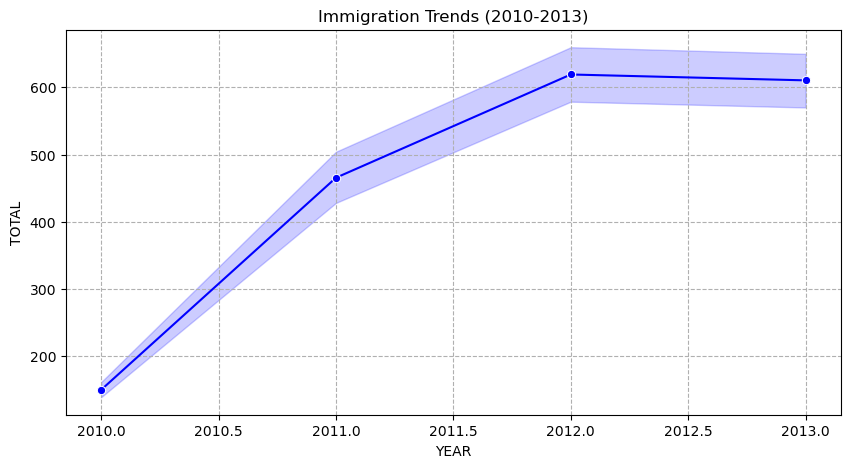

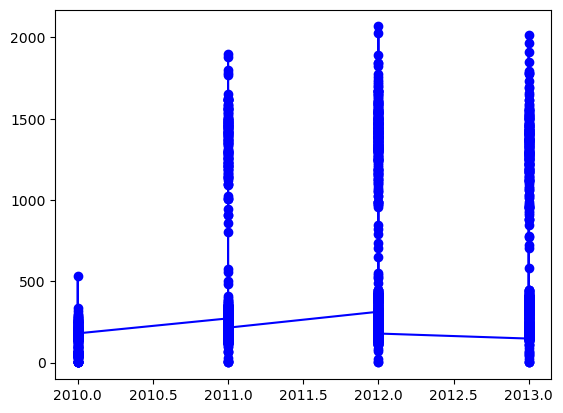

In [4]:
# To visualize immigration trends over the years for a selected country.

df = df_india

df['VISA ISSUE DATE'] = pd.to_datetime(df['VISA ISSUE DATE'])
df['YEAR'] = df['VISA ISSUE DATE'].dt.year
df['YEAR'].head()

visa_columns = df.columns[3:-1]
# visa_columns

df['TOTAL'] = df[visa_columns].sum(axis=1)  # axis=1: Sums the values in each row (result is 1 value per row).

# country_year_group = df.groupby(['COUNTRY', 'YEAR'])['TOTAL'].sum().reset_index()
# country_total = df.groupby('COUNTRY')['TOTAL'].sum().sort_values(ascending=False).reset_index()
# top_5_countries = country_total.head(5)
# country_visa_breakdown = df.groupby('COUNTRY')[visa_cols].sum().reset_index()

country = df[df['COUNTRY'] == 'BANGLADESH']

plt.figure(figsize=(10,5))
sns.lineplot(data=country,x='YEAR', y='TOTAL', marker='o', color = 'blue')
plt.title(f'Immigration Trends (2010-2013)')
plt.grid(True, linestyle='--')
plt.show()


plt.plot(country['YEAR'], country['TOTAL'], marker='o', color = 'blue')
plt.show()

Text(0.5, 1.0, 'Cumulative Immigration Trends Over Time')

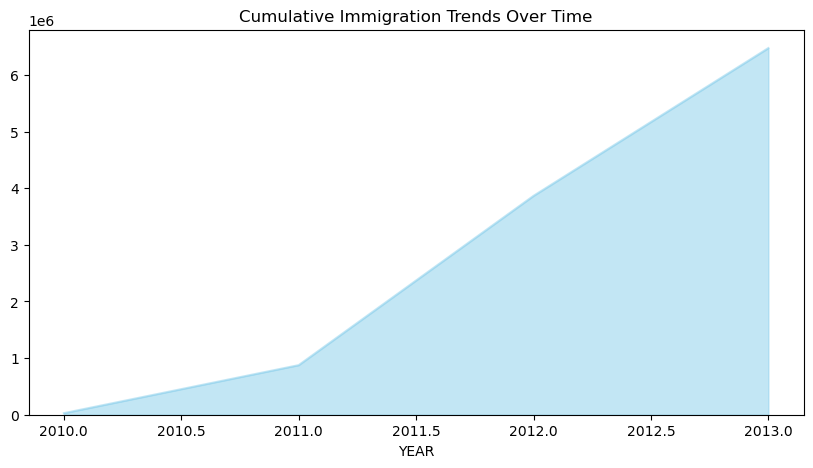

In [5]:
# To represent cumulative immigration trends.

plt.figure(figsize=(10, 5))
yearly_cumulative = df.groupby('YEAR')['TOTAL'].sum().cumsum()
yearly_cumulative.plot(kind='area', color='skyblue', alpha=0.5)  # alpha is contrast value
# df['cumsum'] = df.groupby('YEAR')['TOTAL'].sum().cumsum() 
# plt.plot(df['YEAR'], df['cumsum'])
plt.title('Cumulative Immigration Trends Over Time')

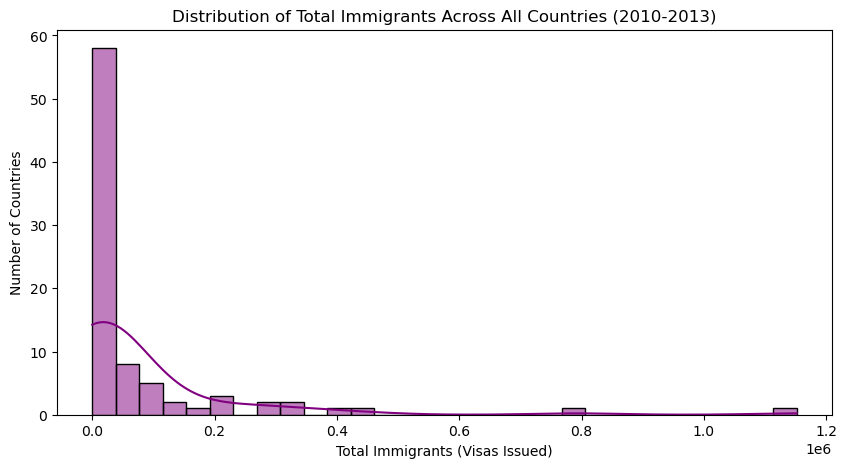

In [20]:
# To show the distribution of total immigrants across all countries.

country_totals = df.groupby('COUNTRY')['TOTAL'].sum().reset_index() # reset index converts DataFrame into Series
plt.figure(figsize=(10,5))
sns.histplot(country_totals['TOTAL'], bins=30, kde=True, color='purple')
plt.title('Distribution of Total Immigrants Across All Countries (2010-2013)')
plt.xlabel('Total Immigrants (Visas Issued)')
plt.ylabel('Number of Countries')
plt.show()



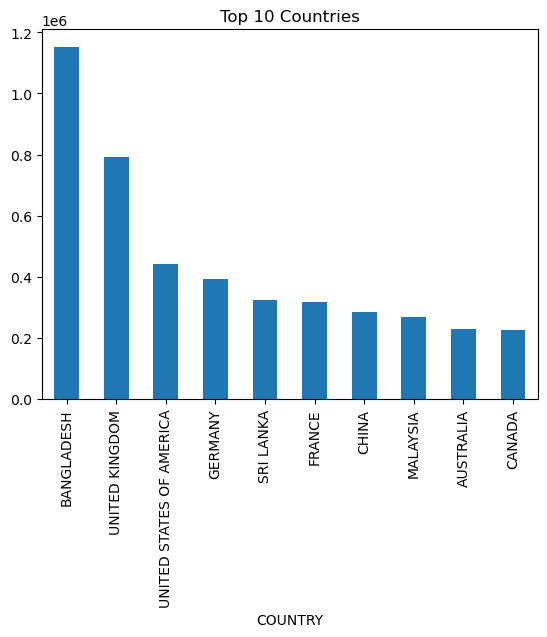

In [7]:
# To compare immigration numbers across different countries.

country_totals = df.groupby('COUNTRY')['TOTAL'].sum().sort_values(ascending=False)

plt.figure()
country_totals.head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

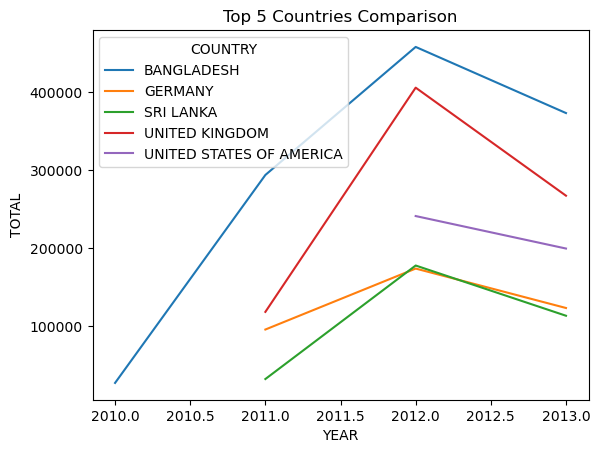

In [8]:
# To show the proportion of immigration from the top 5 countries.

top5 = country_totals.head(5).index

df_top5 = df[df['COUNTRY'].isin(top5)]

grouped = df_top5.groupby(['YEAR','COUNTRY'])['TOTAL'].sum().reset_index()

sns.lineplot(data=grouped, x='YEAR', y='TOTAL', hue='COUNTRY')
plt.title("Top 5 Countries Comparison")
plt.show()

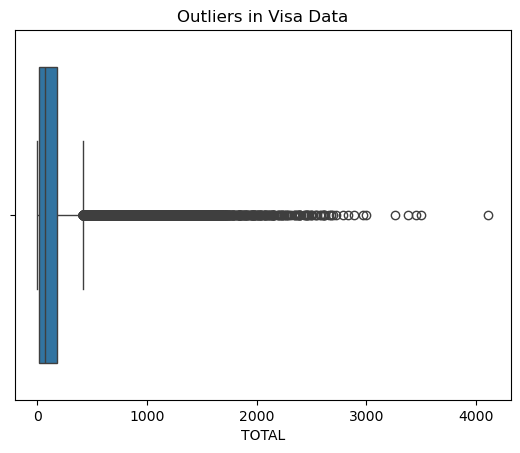

In [9]:
# To analyze statistical distribution and detect outliers in immigration data.

plt.figure()
sns.boxplot(x=df['TOTAL'])
plt.title("Outliers in Visa Data")
plt.show()

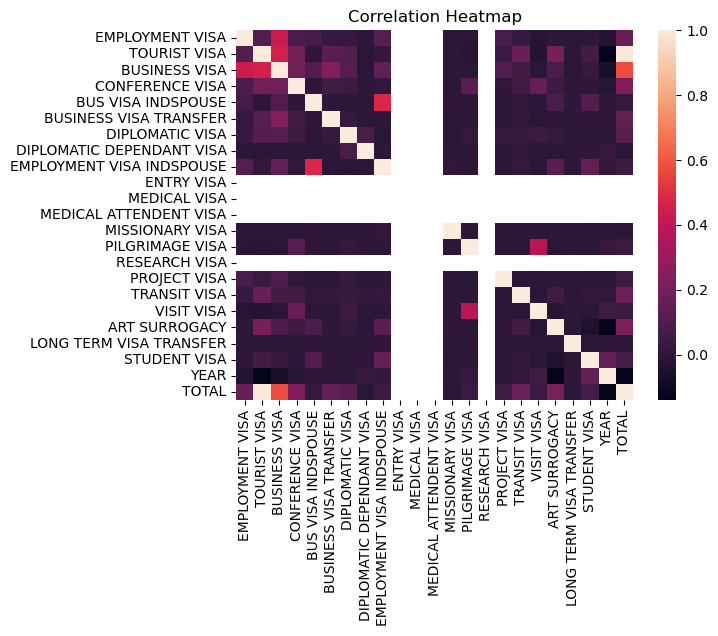

In [10]:
# To explore relationships between different numerical features.

numeric_df = df.select_dtypes(include=np.number)

plt.figure()
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

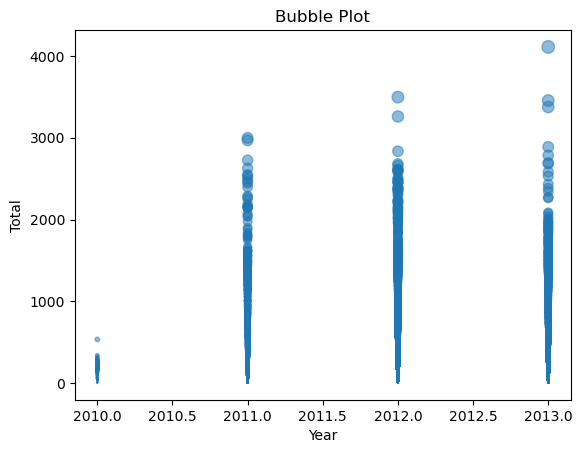

In [11]:
# To enhance scatter plots by adding another variable as bubble size.

plt.figure()
plt.scatter(df['YEAR'], df['TOTAL'], s=df['TOTAL']/50, alpha=0.5)
plt.title("Bubble Plot")
plt.xlabel("Year")
plt.ylabel("Total")
plt.show()

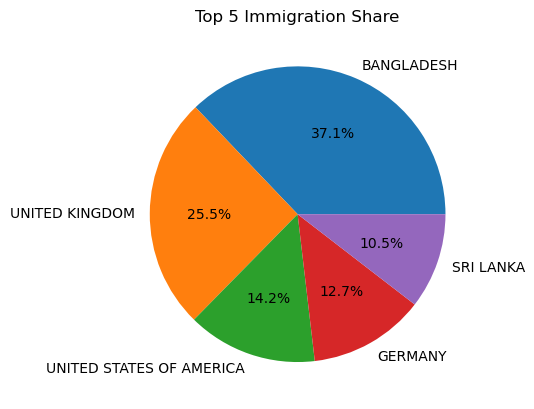

In [12]:
# To visually represent the immigration count of top 5 countries.

top5_values = country_totals.head(5)

plt.figure()
plt.pie(top5_values, labels=top5_values.index, autopct='%1.1f%%')
plt.title("Top 5 Immigration Share")
plt.show()


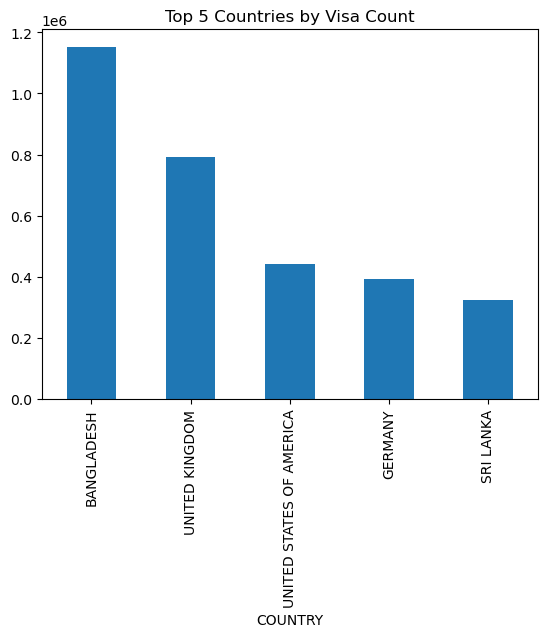

In [13]:
# To depict country names based on the magnitude of immigration numbers.

top5_values.plot(kind='bar')
plt.title("Top 5 Countries by Visa Count")
plt.show()

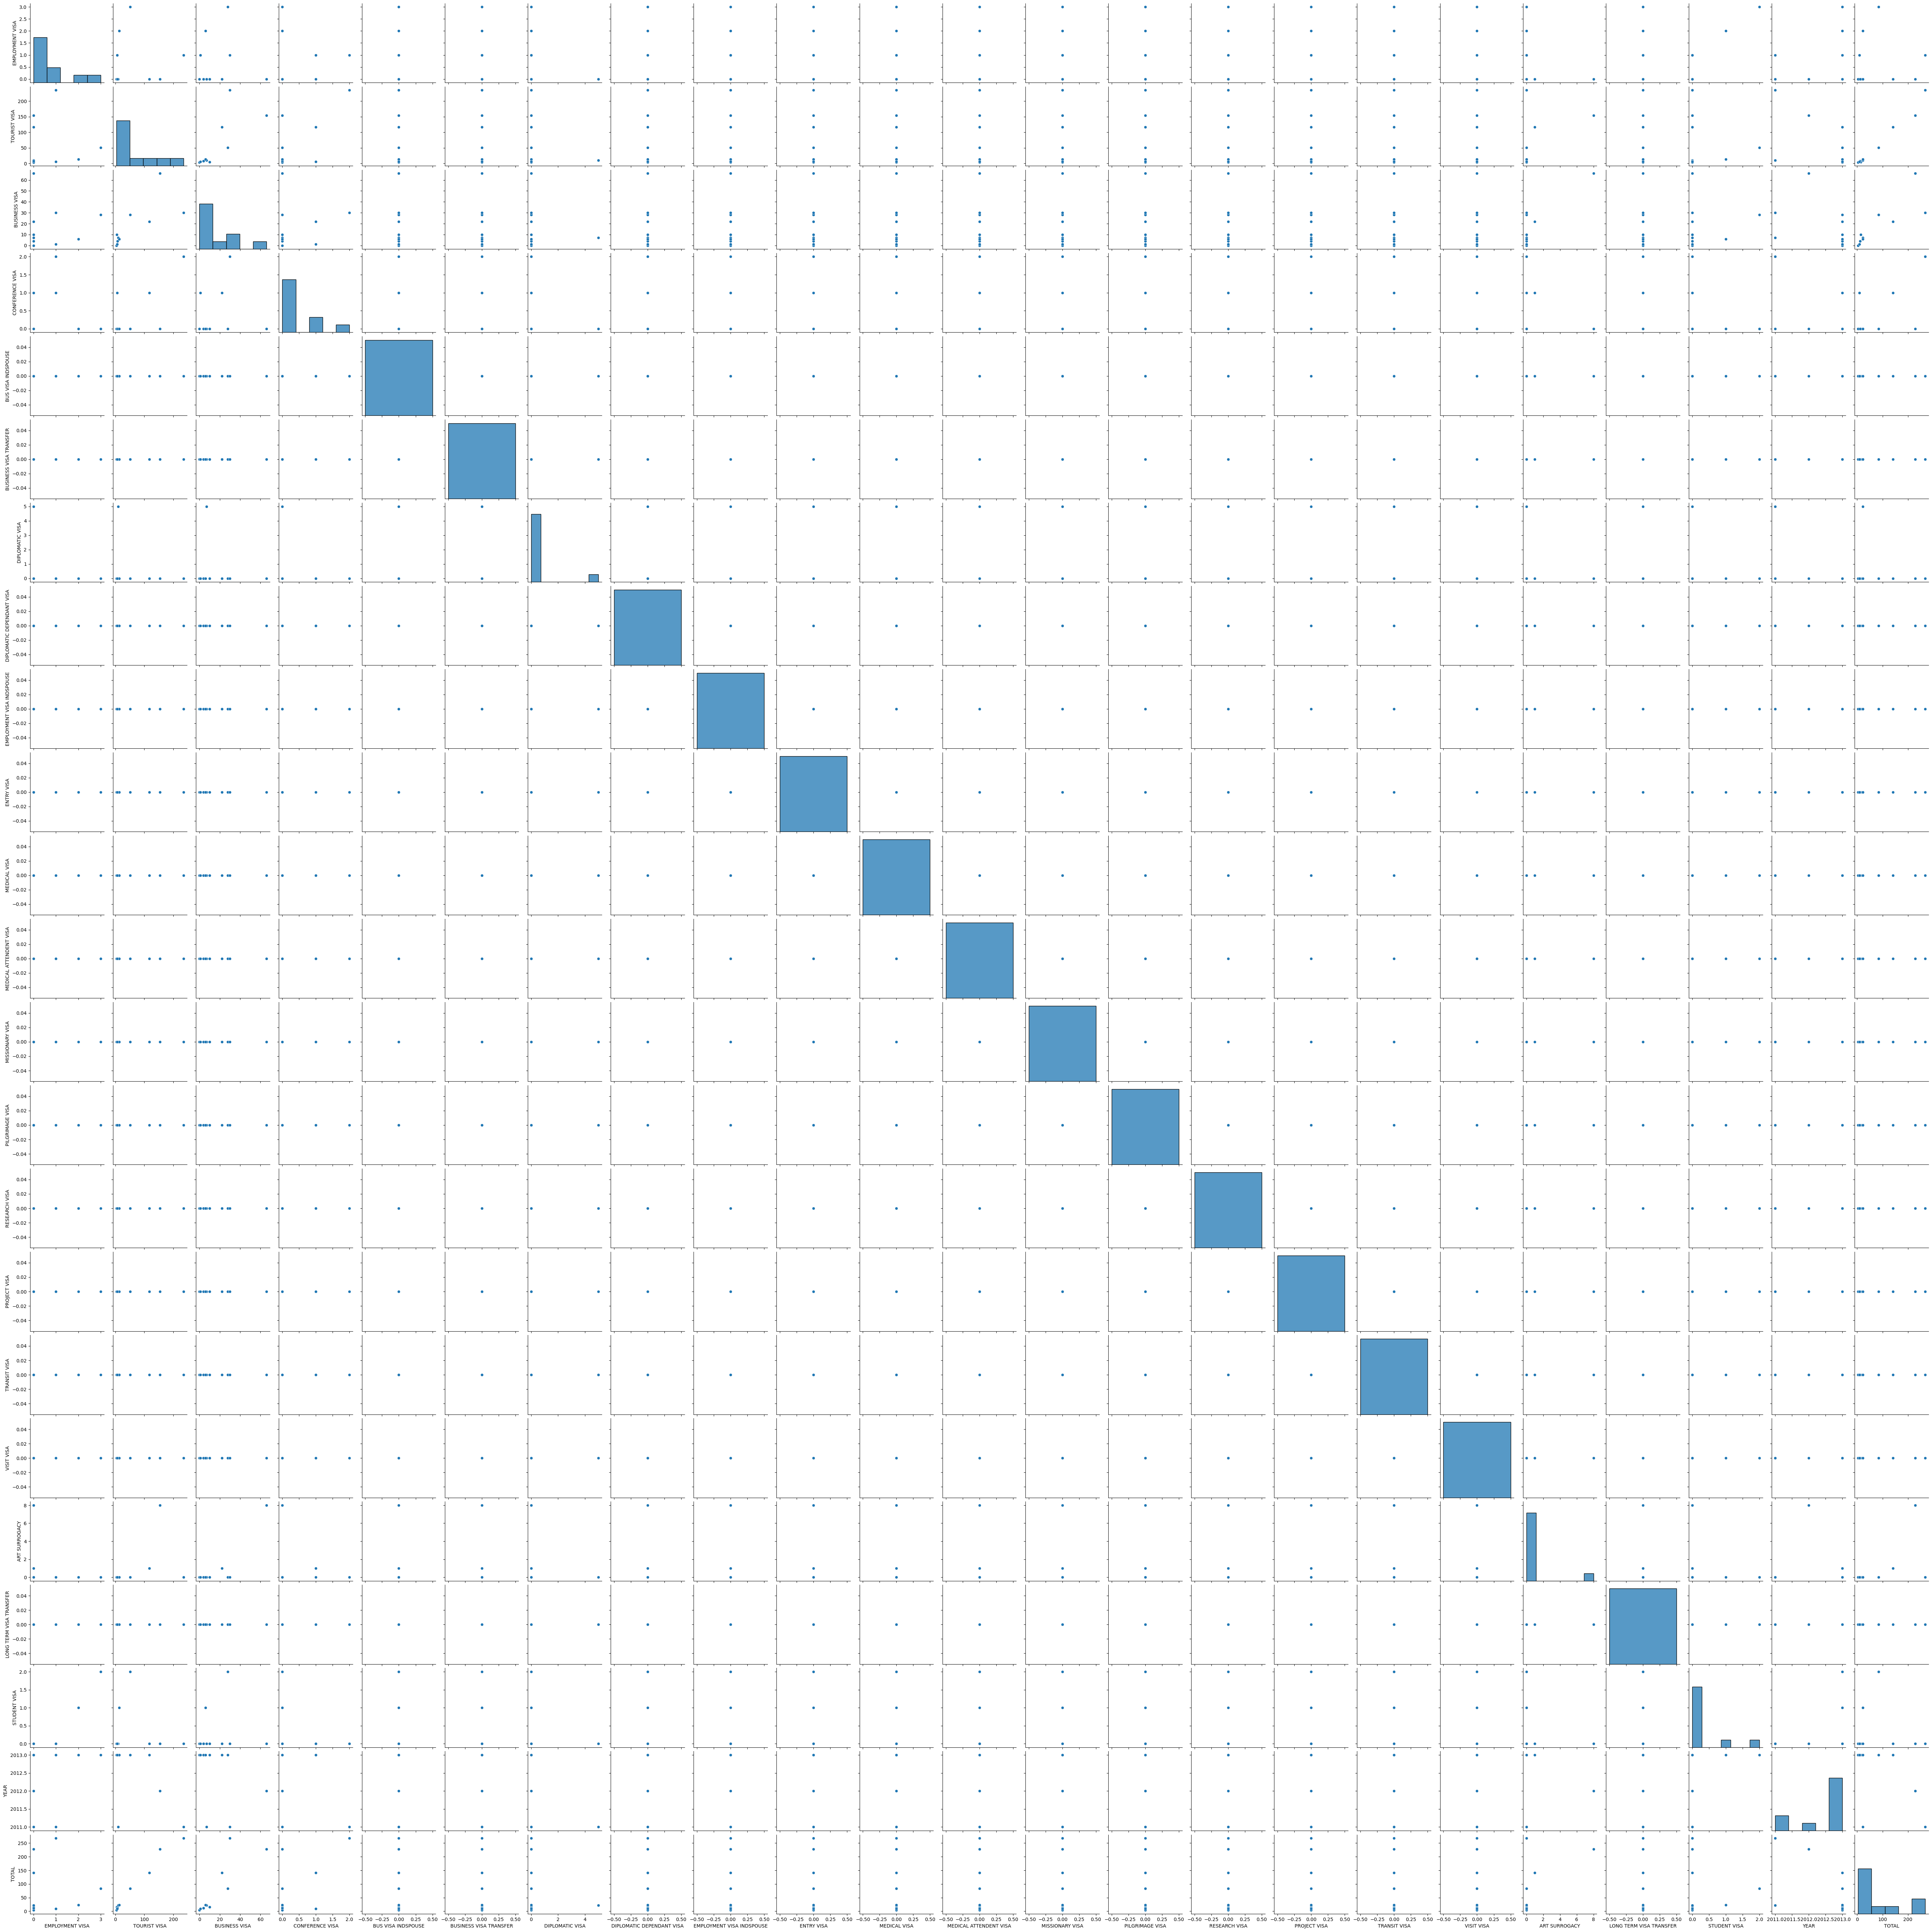

In [14]:
#  To identify trends and correlations in immigration data using Seaborn.
numeric_df = df.select_dtypes(include=np.number)
sns.pairplot(numeric_df.sample(10))  # sample to avoid lag
plt.show()